Analyzing: Group 1 (/transfer/UniTalker-main/results1/train.log)
Analyzing: Group 2 (/transfer/UniTalker-main/results2/train.log)
Analyzing: Group 3 (/transfer/UniTalker-main/results3/train.log)
Analyzing: Group 4 (/transfer/UniTalker-main/results4/train.log)

Experiment Summary Results:
  Group  Final Train Loss  Final Val Loss  Final Test Loss  Min Val Loss  Min Val Loss Epoch  Min Test Loss  Min Test Loss Epoch  Final Val LVE  Final Val LVD  Final Test LVE  Final Test LVD
Group 1      2.000000e-07    9.800000e-07     9.700000e-07  9.500000e-07                  56   9.700000e-07                   72       0.000011       0.002732        0.000012        0.002783
Group 2      2.000000e-07    9.800000e-07     9.700000e-07  9.500000e-07                  51   9.600000e-07                   90       0.000012       0.002738        0.000012        0.002778
Group 3      2.000000e-07    9.700000e-07     9.700000e-07  9.500000e-07                  85   9.600000e-07                   90       0.0

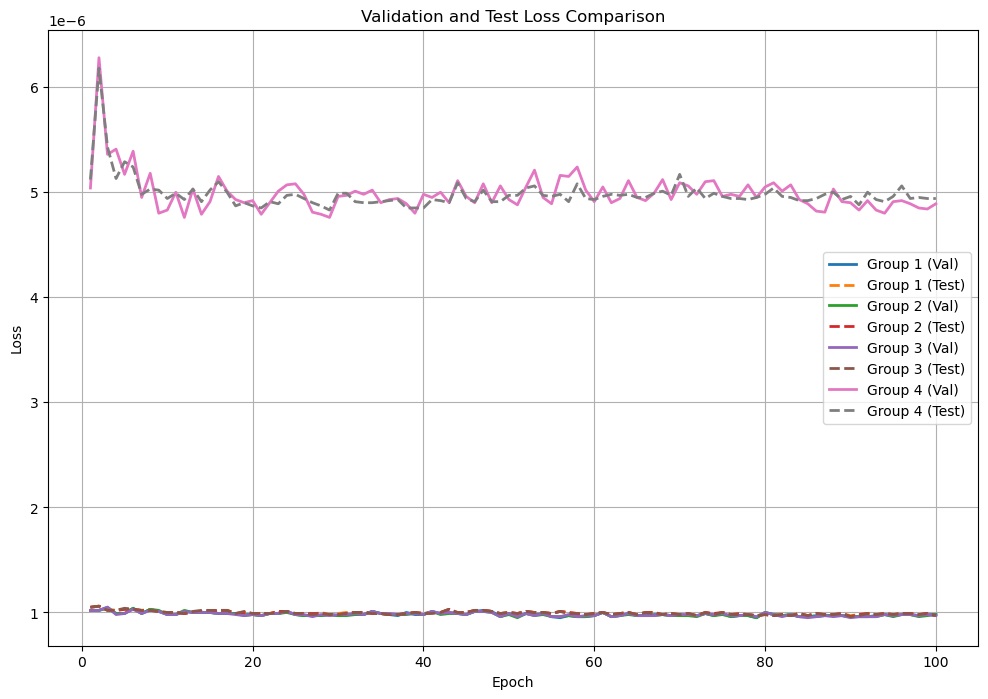

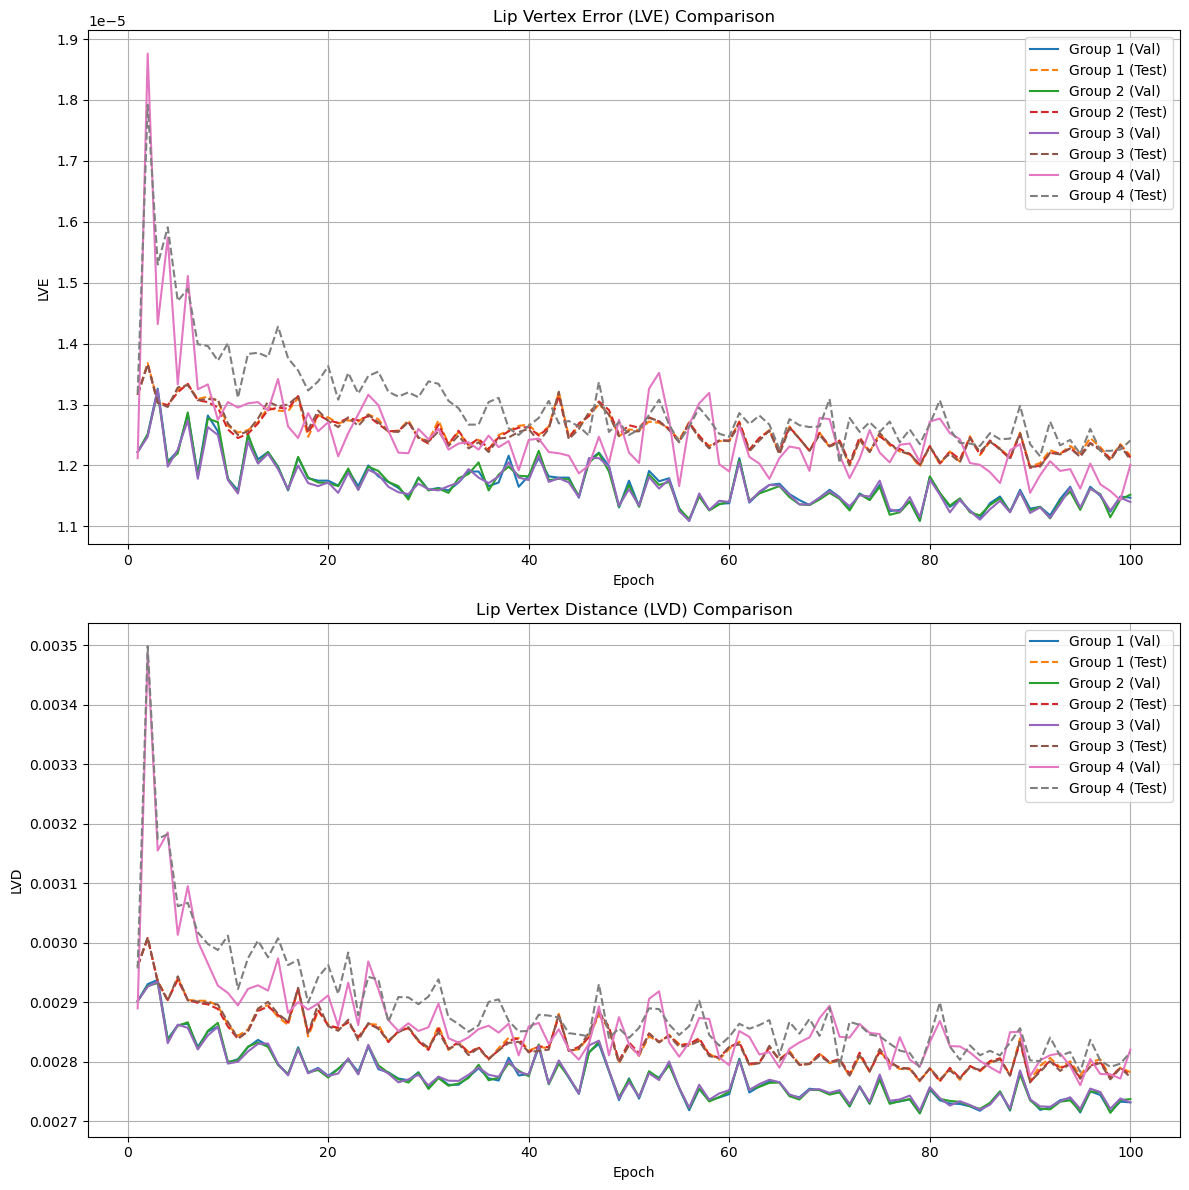

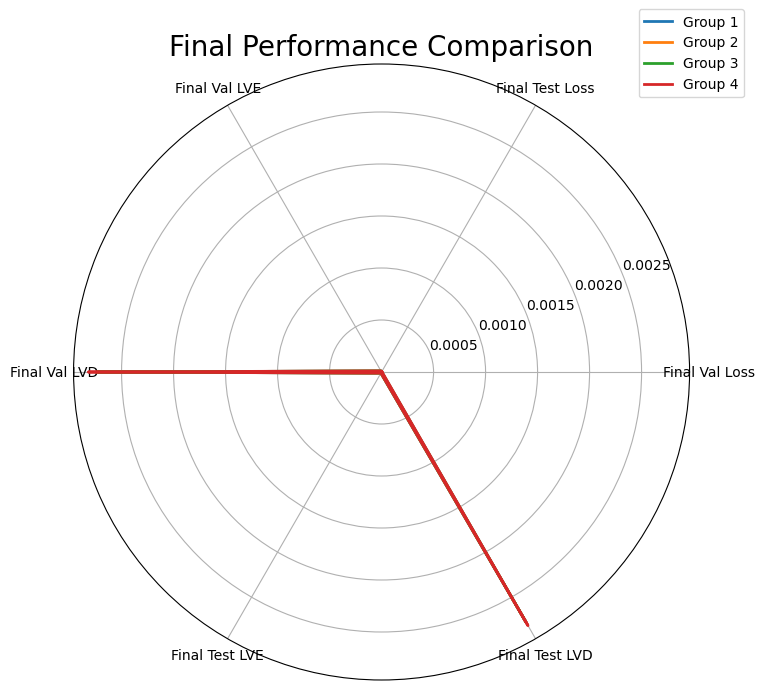

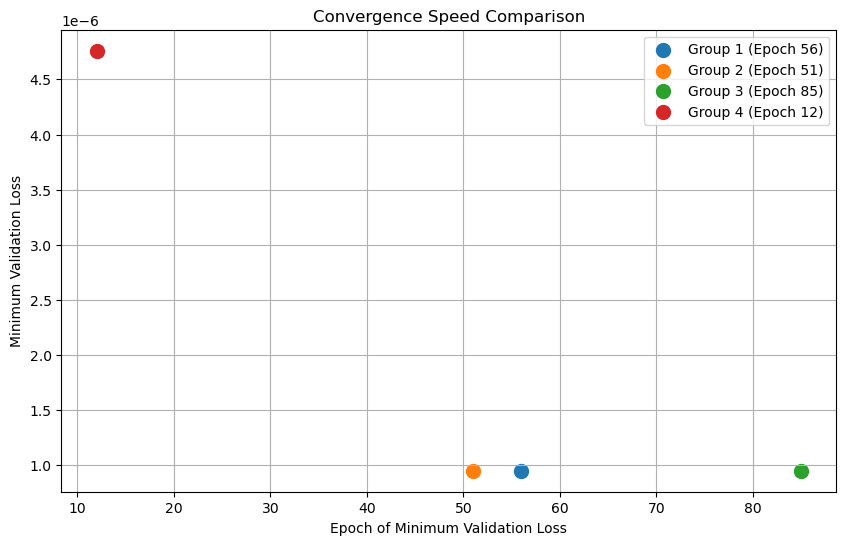

In [1]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator

def parse_log_file(log_path):
    """Parse a single training log file"""
    data = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'test_loss': [],
        'val_LVE': [],
        'val_LVD': [],
        'test_LVE': [],
        'test_LVD': []
    }
    
    with open(log_path, 'r') as f:
        for line in f:
            # Parse training loss
            train_match = re.search(r'TRAIN Epoch: (\d+).*rec_L2_loss_mixed_dataset: ([\d\.e-]+)', line)
            if train_match:
                epoch = int(train_match.group(1))
                loss = float(train_match.group(2))
                data['epoch'].append(epoch)
                data['train_loss'].append(loss)
            
            # Parse validation loss
            val_match = re.search(r'VAL\s+Epoch: (\d+).*rec_L2_loss_mixed_dataset: ([\d\.e-]+), LVE_mixed_dataset: ([\d\.e-]+), LVD_mixed_dataset: ([\d\.e-]+)', line)
            if val_match:
                epoch = int(val_match.group(1))
                loss = float(val_match.group(2))
                lve = float(val_match.group(3))
                lvd = float(val_match.group(4))
                data['val_loss'].append(loss)
                data['val_LVE'].append(lve)
                data['val_LVD'].append(lvd)
            
            # Parse test loss
            test_match = re.search(r'TEST\s+Epoch: (\d+).*rec_L2_loss_mixed_dataset: ([\d\.e-]+), LVE_mixed_dataset: ([\d\.e-]+), LVD_mixed_dataset: ([\d\.e-]+)', line)
            if test_match:
                epoch = int(test_match.group(1))
                loss = float(test_match.group(2))
                lve = float(test_match.group(3))
                lvd = float(test_match.group(4))
                data['test_loss'].append(loss)
                data['test_LVE'].append(lve)
                data['test_LVD'].append(lvd)
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Calculate key metrics
    if not df.empty:
        final_epoch = df['epoch'].max()
        final_row = df[df['epoch'] == final_epoch].iloc[0]
        
        return {
            'log_path': log_path,
            'final_train_loss': final_row['train_loss'],
            'final_val_loss': final_row['val_loss'],
            'final_test_loss': final_row['test_loss'],
            'final_val_LVE': final_row['val_LVE'],
            'final_val_LVD': final_row['val_LVD'],
            'final_test_LVE': final_row['test_LVE'],
            'final_test_LVD': final_row['test_LVD'],
            'min_val_loss': df['val_loss'].min(),
            'min_val_loss_epoch': df.loc[df['val_loss'].idxmin(), 'epoch'],
            'min_test_loss': df['test_loss'].min(),
            'min_test_loss_epoch': df.loc[df['test_loss'].idxmin(), 'epoch'],
            'full_data': df
        }
    return None

def analyze_experiments(log_files):
    """Analyze all experiment logs"""
    results = {}
    summary_data = []
    
    for name, path in log_files.items():
        print(f"Analyzing: {name} ({path})")
        result = parse_log_file(path)
        if result:
            results[name] = result
            summary_data.append({
                'Group': name,
                'Final Train Loss': result['final_train_loss'],
                'Final Val Loss': result['final_val_loss'],
                'Final Test Loss': result['final_test_loss'],
                'Min Val Loss': result['min_val_loss'],
                'Min Val Loss Epoch': result['min_val_loss_epoch'],
                'Min Test Loss': result['min_test_loss'],
                'Min Test Loss Epoch': result['min_test_loss_epoch'],
                'Final Val LVE': result['final_val_LVE'],
                'Final Val LVD': result['final_val_LVD'],
                'Final Test LVE': result['final_test_LVE'],
                'Final Test LVD': result['final_test_LVD']
            })
    
    # Set output directory
    output_dir = "experiment_analysis"
    os.makedirs(output_dir, exist_ok=True)
    
    # Save summary tables
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_csv(os.path.join(output_dir, "experiment_summary.csv"), index=False)
    summary_df.to_html(os.path.join(output_dir, "experiment_summary.html"), index=False)
    
    # Generate visualizations
    generate_visualizations(results, output_dir)
    
    return results, summary_df

def generate_visualizations(results, output_dir):
    """Generate visualizations"""
    # 1. Loss curve comparison
    plt.figure(figsize=(12, 8))
    for name, data in results.items():
        df = data['full_data']
        plt.plot(df['epoch'], df['val_loss'], label=f"{name} (Val)", linewidth=2)
        plt.plot(df['epoch'], df['test_loss'], '--', label=f"{name} (Test)", linewidth=2)
    
    plt.title("Validation and Test Loss Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, "loss_comparison.png"), dpi=300)
    
    # 2. LVE/LVD comparison
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
    
    # LVE comparison
    for name, data in results.items():
        df = data['full_data']
        ax1.plot(df['epoch'], df['val_LVE'], label=f"{name} (Val)")
        ax1.plot(df['epoch'], df['test_LVE'], '--', label=f"{name} (Test)")
    
    ax1.set_title("Lip Vertex Error (LVE) Comparison")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("LVE")
    ax1.legend()
    ax1.grid(True)
    
    # LVD comparison
    for name, data in results.items():
        df = data['full_data']
        ax2.plot(df['epoch'], df['val_LVD'], label=f"{name} (Val)")
        ax2.plot(df['epoch'], df['test_LVD'], '--', label=f"{name} (Test)")
    
    ax2.set_title("Lip Vertex Distance (LVD) Comparison")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("LVD")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "lve_lvd_comparison.png"), dpi=300)
    
    # 3. Final performance radar chart
    metrics = ['Final Val Loss', 'Final Test Loss', 'Final Val LVE', 'Final Val LVD', 'Final Test LVE', 'Final Test LVD']
    groups = list(results.keys())
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, polar=True)
    
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # Close the figure
    
    for name in groups:
        values = [
            results[name]['final_val_loss'],
            results[name]['final_test_loss'],
            results[name]['final_val_LVE'],
            results[name]['final_val_LVD'],
            results[name]['final_test_LVE'],
            results[name]['final_test_LVD']
        ]
        values += values[:1]  # Close the figure
        ax.plot(angles, values, linewidth=2, label=name)
        ax.fill(angles, values, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    plt.title("Final Performance Comparison", size=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    plt.savefig(os.path.join(output_dir, "radar_chart.png"), dpi=300)
    
    # 4. Convergence speed comparison
    plt.figure(figsize=(10, 6))
    for name, data in results.items():
        min_epoch = data['min_val_loss_epoch']
        min_loss = data['min_val_loss']
        plt.scatter(min_epoch, min_loss, s=100, label=f"{name} (Epoch {min_epoch})")
    
    plt.title("Convergence Speed Comparison")
    plt.xlabel("Epoch of Minimum Validation Loss")
    plt.ylabel("Minimum Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, "convergence_speed.png"), dpi=300)

if __name__ == "__main__":
    # Configure your experiment log file paths
    log_files = {
        "Group 1": "/transfer/UniTalker-main/results1/train.log",
        "Group 2": "/transfer/UniTalker-main/results2/train.log",
        "Group 3": "/transfer/UniTalker-main/results3/train.log",
        "Group 4": "/transfer/UniTalker-main/results4/train.log"
    }
    
    # Run analysis
    results, summary_df = analyze_experiments(log_files)
    
    # Print summary results
    print("\nExperiment Summary Results:")
    print(summary_df.to_string(index=False))
    
    print("\nAnalysis complete! Results saved in: experiment_analysis/")    